# House Price Prediction using Linear Regression

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

## Problem Statement

* Given a dataset that describes the functionality of houses. Now, based on the given features, we have to predict the house price.

## Defining a DataFrame

In [2]:
df = pd.read_csv('House_Price_Prediction_Dataset.csv')

## EDA - Exploratory Data Analysis

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [5]:
df.shape[0]

2000

In [6]:
df.shape[1]

10

In [7]:
len(df.columns)

10

In [8]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [9]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [11]:
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [12]:
df.nunique()

Id           2000
Area         1622
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1999
dtype: int64

In [13]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [14]:
df.isnull().sum().sum()

0

In [15]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Observations:
1. Data Strength - 2000

2. Number of random variables - 10

3. None of the columns contain null values

4. Columns price, area, bedrooms, bathrooms, floors, yearbuilt has numerical values

5. Columns location, condition, garage has object values

In [16]:
df.Garage.unique()

array(['No', 'Yes'], dtype=object)

In [17]:
df.Garage.value_counts()

No     1038
Yes     962
Name: Garage, dtype: int64

In [18]:
# Yes -> 1
# No  -> 0

df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

In [19]:
df.Garage.dtypes

dtype('int64')

In [20]:
df.Location.unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [21]:
df.Location.value_counts()

Downtown    558
Urban       485
Suburban    483
Rural       474
Name: Location, dtype: int64

In [22]:
# Downtown -> 3
# Urban    -> 2
# Suburban -> 1
# Rural    -> 0

df['Location'] = df['Location'].map({'Downtown': 3, 'Urban': 2, 'Suburban': 1, 'Rural': 0})

In [23]:
df.Condition.unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [24]:
df.Condition.value_counts()

Fair         521
Excellent    511
Poor         507
Good         461
Name: Condition, dtype: int64

In [25]:
# Excellent -> 3
# Good      -> 2
# Fair      -> 1
# Poor      -> 0

df['Condition'] = df['Condition'].map({'Excellent': 3, 'Good': 2, 'Fair': 1, 'Poor': 0})

In [26]:
# Drop Id column (not a feature)
df.drop('Id', axis=1, inplace=True)

In [27]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,3,3,0,149919
1,4272,5,4,3,1958,3,3,0,424998
2,3592,2,2,3,1938,3,2,0,266746
3,966,4,2,2,1902,1,1,1,244020
4,4926,1,4,2,1975,3,1,1,636056


## Manipulation:
1. Changed the categorical values to numerical values for columns (Garage, Location, Condition)

In [28]:
df.dtypes

Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object

In [29]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,1.563500,1.488000,0.481000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,1.130755,1.126273,0.499764,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,0.000000,0.000000,0.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,1.000000,0.000000,0.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,2.000000,1.000000,0.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,3.000000,3.000000,1.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,3.000000,3.000000,1.000000,999656.000000


In [30]:
df.corr()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.016973,-0.006540,-0.003441,0.001542
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,0.010886,-0.011042,-0.041713,-0.003471
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,0.026063,-0.000497,0.004057,-0.015737
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.010019,-0.020121,-0.004635,0.055890
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.025187,-0.002142,-0.011703,0.004845
Location,0.016973,0.010886,0.026063,0.010019,0.025187,1.000000,0.026720,-0.048764,-0.018125
Condition,-0.006540,-0.011042,-0.000497,-0.020121,-0.002142,0.026720,1.000000,-0.037733,-0.010576
Garage,-0.003441,-0.041713,0.004057,-0.004635,-0.011703,-0.048764,-0.037733,1.000000,0.002842
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,-0.018125,-0.010576,0.002842,1.000000


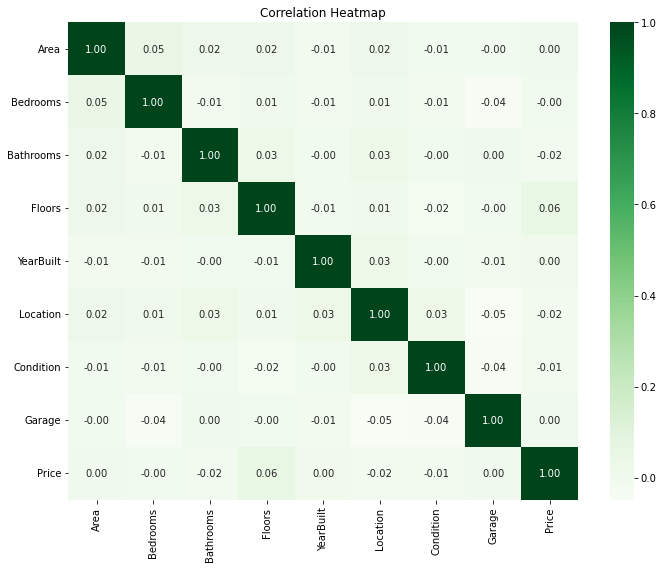

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

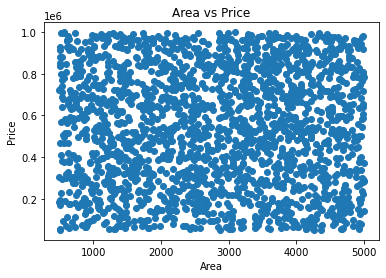

In [32]:
plt.scatter(df.Area, df.Price)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

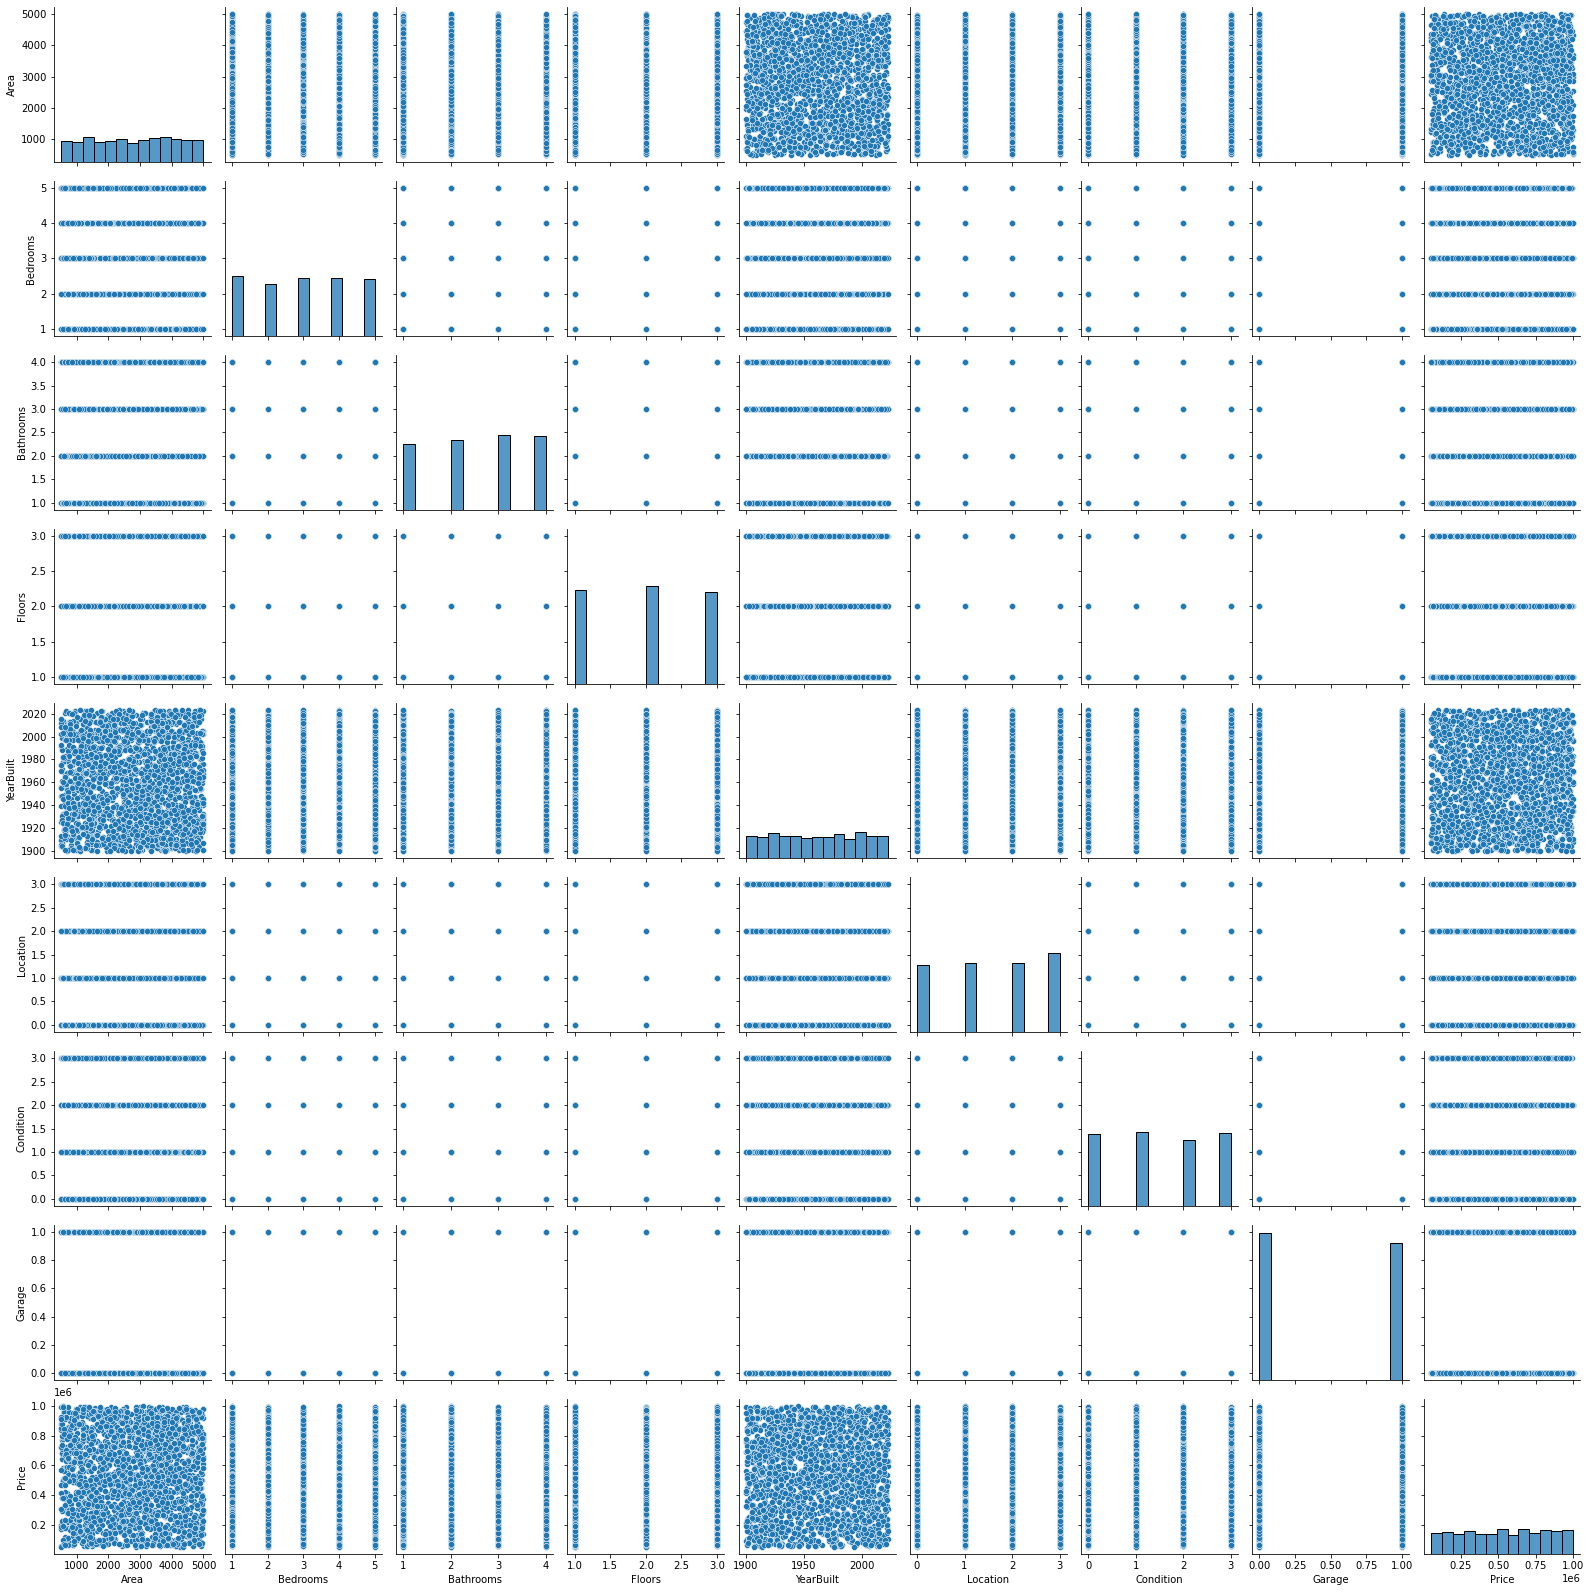

In [33]:
sns.pairplot(df)

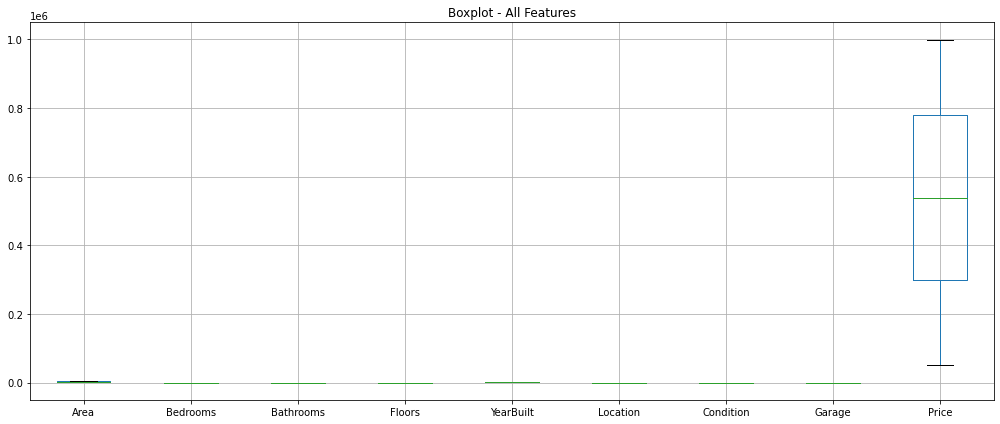

In [34]:
plt.figure(figsize=(14, 6))
df.boxplot()
plt.title('Boxplot - All Features')
plt.tight_layout()
plt.show()

<AxesSubplot:>

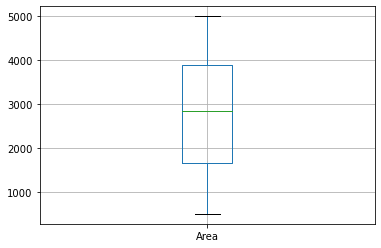

In [35]:
df[['Area']].boxplot()

<Axes: >

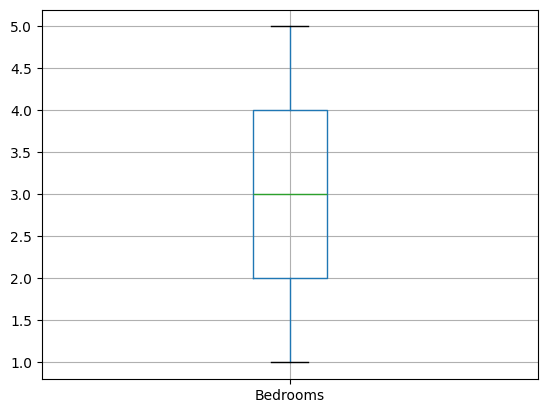

In [36]:
df[['Bedrooms']].boxplot()

In [36]:
# How many values are there where bedrooms are more than 4
len(df.Bedrooms.loc[df.Bedrooms > 4])

403

<Axes: >

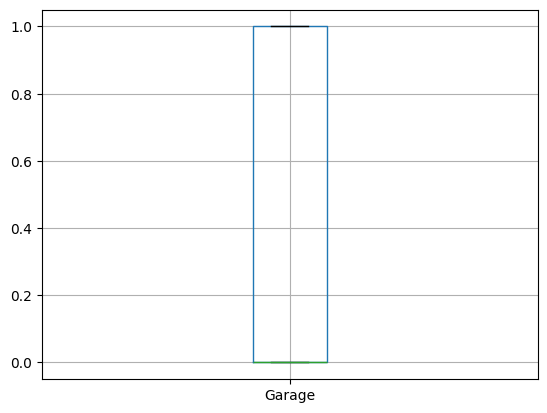

In [38]:
df[['Garage']].boxplot()

In [37]:
len(df.Garage.loc[df.Garage == 0])

1038

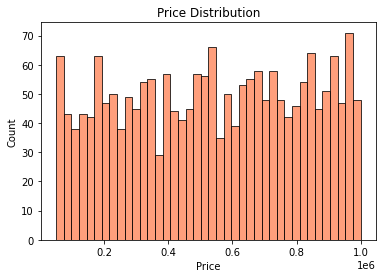

In [38]:
sns.histplot(df.Price, bins=40, color='coral')
plt.title('Price Distribution')
plt.show()

In [39]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,3,3,0,149919
1,4272,5,4,3,1958,3,3,0,424998
2,3592,2,2,3,1938,3,2,0,266746
3,966,4,2,2,1902,1,1,1,244020
4,4926,1,4,2,1975,3,1,1,636056


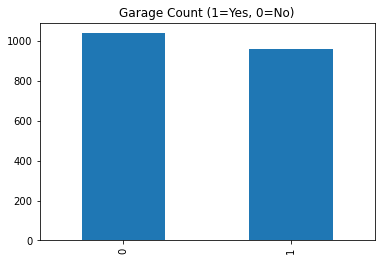

In [40]:
df.Garage.value_counts().plot.bar()
plt.title('Garage Count (1=Yes, 0=No)')
plt.show()

In [41]:
# What is the price of house where bedrooms are 4 and bathrooms are 2
df.loc[df.Bedrooms == 4, ['Price', 'Bedrooms', 'Bathrooms']][df.Bathrooms == 2]

,Price,Bedrooms,Bathrooms
3,244020,4,2
26,745494,4,2
103,344721,4,2
104,188783,4,2
114,256084,4,2
...,...,...,...
1866,110263,4,2
1916,160675,4,2
1920,265196,4,2
1944,776262,4,2


## Splitting the Dataset

In [42]:
df.head(2)

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,3,3,0,149919
1,4272,5,4,3,1958,3,3,0,424998


In [43]:
x = df.drop('Price', axis=1)
y = df.Price

In [44]:
df.Price.ndim

1

In [45]:
df.drop('Price', axis=1).ndim

2

In [46]:
df.Price

0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64

In [47]:
df[df.columns[1:]]

,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,5,4,3,1970,3,3,0,149919
1,5,4,3,1958,3,3,0,424998
2,2,2,3,1938,3,2,0,266746
3,4,2,2,1902,1,1,1,244020
4,1,4,2,1975,3,1,1,636056
...,...,...,...,...,...,...,...,...
1995,5,4,3,1923,1,0,0,295620
1996,5,2,1,2019,1,0,1,580929
1997,5,1,2,1903,0,0,0,476925
1998,3,1,2,1936,2,3,1,161119


In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [49]:
len(x_train)

1600

In [50]:
len(x_test)

400

In [51]:
len(y_train)

1600

In [52]:
len(y_test)

400

In [53]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
x_test_df = x_test.copy()  # keep original for plotting

## Choosing the Model

In [54]:
model = LinearRegression()

## Training / Fitting the Model

In [55]:
model.fit(x_train_scaled, y_train)

LinearRegression()

In [56]:
# Intercept Values
model.intercept_

536183.7

In [57]:
# Coefficient Values
model.coef_

array([  -399.54486691,    119.87893154, -11058.15037891,  18900.87334868,
         4043.1168218 ,  -3442.00375742,  -5296.3839652 ,   1399.19672749])

In [58]:
# y = c + m(1)*x(1) + ... + m(n)*x(n)
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
coef_df

,Feature,Coefficient
0,Area,-399.544867
1,Bedrooms,119.878932
2,Bathrooms,-11058.150379
3,Floors,18900.873349
4,YearBuilt,4043.116822
5,Location,-3442.003757
6,Condition,-5296.383965
7,Garage,1399.196727


## Prediction

In [59]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [60]:
pred_y = model.predict(x_test_scaled)

In [61]:
pred_y

array([514876.535712  , 543803.80036236, 494677.29133769, 550385.61138738,
       563513.34479421, 548390.90171749, 548600.54096325, 550317.98501276,
       553865.23685659, 571434.83783619, 536613.29673155, 581775.87085547,
       508906.32435302, 527330.27264181, 520540.55821559, 537025.8149369 ,
       545485.14777248, 545017.66236189, 563609.22694875, 515941.4494498 ,
       541428.46395499, 511955.39986546, 520248.38837644, 576468.87038132,
       548278.14118923, 535538.34567691, 519098.80600054, 511516.93640801,
       534920.75508451, 481801.71187116, 497193.94977896, 539850.54297804,
       556933.58076897, 571600.49886628, 515619.93594948, 502193.98927592,
       569128.68903214, 575113.92627872, 530300.92631532, 522010.43184424,
       481594.63422864, 527141.12090541, 536126.89478249, 541133.86760525,
       539888.68518076, 546664.14875634, 552119.21410499, 516120.53765114,
       541765.8588075 , 521771.03436021, 493393.95076659, 535752.35457743,
       554509.90635348, 5

In [62]:
newdf = pd.DataFrame({'Actual Value': y_test.values, 'Predicted Value': pred_y})

In [63]:
newdf

,Actual Value,Predicted Value
0,514764,514876.535712
1,694256,543803.800362
2,66375,494677.291338
3,650243,550385.611387
4,223285,563513.344794
...,...,...
395,386940,566457.843998
396,632570,552037.567615
397,494049,522999.917654
398,562193,530292.924743


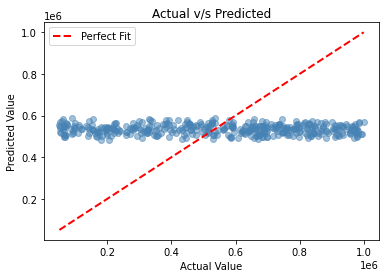

In [64]:
plt.scatter(newdf['Actual Value'], newdf['Predicted Value'], alpha=0.5, color='steelblue')
min_val = min(newdf['Actual Value'].min(), newdf['Predicted Value'].min())
max_val = max(newdf['Actual Value'].max(), newdf['Predicted Value'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual v/s Predicted')
plt.legend()
plt.show()

In [65]:
newdf.corr()

,Actual Value,Predicted Value
Actual Value,1.000000,-0.036506
Predicted Value,-0.036506,1.000000


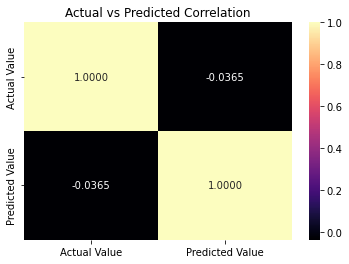

In [66]:
sns.heatmap(newdf.corr(), annot=True, cmap='magma', fmt='.4f')
plt.title('Actual vs Predicted Correlation')
plt.show()

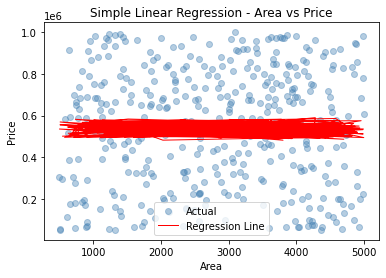

In [67]:
# Simple Linear Regression
plt.scatter(x_test_df['Area'], y_test, alpha=0.4, color='steelblue', label='Actual')
plt.plot(x_test_df['Area'], pred_y, color='red', label='Regression Line', linewidth=1)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Simple Linear Regression - Area vs Price')
plt.legend()
plt.show()

In [68]:
# Custom Prediction
# Input order: [Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage]
inp = np.array([7420, 4, 2, 3, 2000, 3, 3, 1])
inp = inp.reshape(1, -1)
inp_scaled = scaler.transform(inp)
model.predict(inp_scaled)

array([557898.3530267])

## Testing the Model Performance

In [69]:
r2_score(y_test, pred_y)

-0.013700478686581752